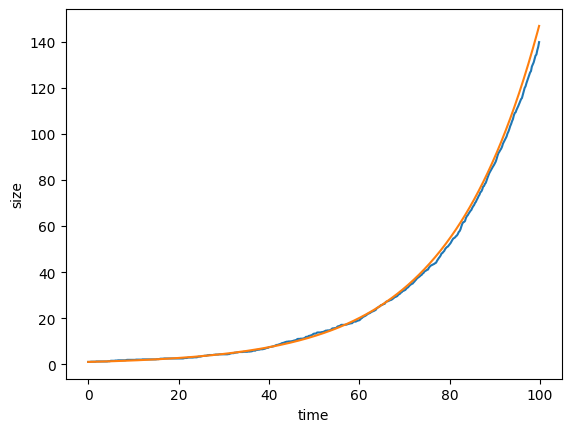

In [106]:
## ----------- Problem 1 --------------

import numpy as np
import numpy.random as rd
rng = rd.default_rng()

def tossCoin(P):
    rv = rng.random()
    return rv < P

# ---- (a) ----
dt = 0.2
P = 0.01
T = 100

def experiment(P, dt, T):
    N = 1
    t = 0
    N_time = [N,]
    # _time = [t,]
    for t in np.arange(dt, T, dt):
        daughters = 0 # counts the total number of daughters occurring in this time step
        for cell in range(N): # loop over all existing cells
            daughters += tossCoin(P) # check whether cell divides
        # daughters = rng.binomial(N,P)
        N += daughters
        N_time.append(N)
        # _time.append(t)
    return N_time

def exponentialFunc(t):
    return np.exp(t*P/dt)



_time = np.arange(0, T, dt)

nExperiments=10
expResults = []
for i in range(nExperiments):
    N_time = experiment(P, dt, T)
    expResults.append(N_time)

# sum over the columns:
# first convert list of lists to numpy array. Then use np.mean, specifying to average over axis 0 (columns)
meanTrajectory_time = np.mean(np.array(expResults), axis=0)

import matplotlib.pyplot as plt

expGrowth_time = [exponentialFunc(tt) for tt in _time]
# plt.plot(_time, N_time)
plt.plot(_time, meanTrajectory_time)
plt.plot(_time, expGrowth_time)
plt.xlabel("time")
plt.ylabel("size")
plt.show()


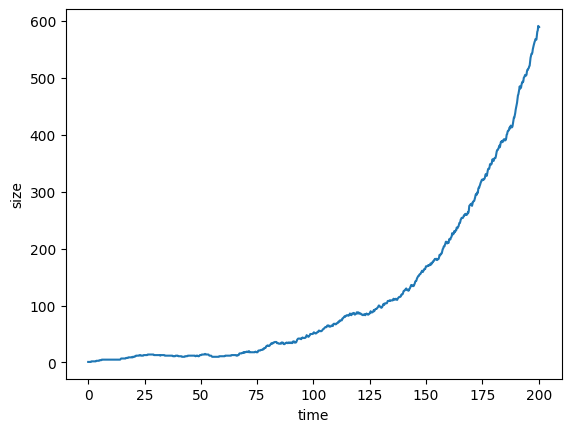

In [96]:

# ---- (b) ----

def experiment(P, Q, N0, dt, T):
    N = N0
    t = 0
    N_time = [N,]
    _time = [t,]
    while t < T:
        t += dt
        daughters = 0 # counts the total number of daughters occurring in this time step
        deaths = 0 # counts the total number of deaths occurring in this time step
        for cell in range(N): # loop over all existing cells
            daughters += tossCoin(P) # check whether cell divides
            deaths += tossCoin(Q) # check whether cell dies

        N += daughters - deaths
        N_time.append(N)
        _time.append(t)
        
    return _time, N_time

P = 0.01
Q = 0.005
dt = 0.2
T = 200
N0 = 1
_time, N_time = experiment(P, Q, N0, dt, T)


plt.plot(_time, N_time)
plt.xlabel("time")
plt.ylabel("size")
plt.show()

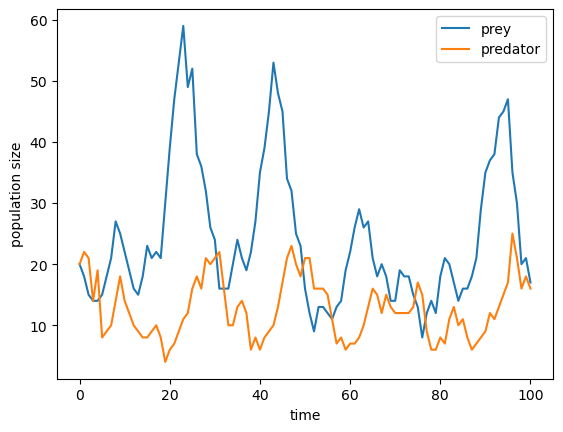

In [9]:
## ---------- Problem 2 ----------

Na = 20 # size of prey population
Nb = 20 # size of predator population

tStep = 1
RateA = 0.7
RateB = 0.3
probEat = 0.1
runTime = 100

Nb_time = [Nb,]
Na_time = [Na,]
for t in np.arange(0,runTime,tStep):

    preyBirths = rng.binomial(Na, RateA*tStep)  # draw reproduction successes from Na Bernoulli trials
    preyDeaths = rng.binomial(Na, (1-(1-probEat)**Nb))  # draw number of succesfull predation attempts (= deaths of prey)
    predBirths = rng.binomial(Nb, RateB*tStep)
    predDeaths = 0
    for pred in range(Nb): # for each predator draw number of succesfull predation attempts
        kills = rng.binomial(preyDeaths, 1/Nb)
        if kills==0: # if unsuccessful, kill predator
            predDeaths += 1

    # update prey and predator populations size
    Na = Na + preyBirths - preyDeaths
    Nb = Nb + predBirths - predDeaths

    # add populations sizes to time array
    Na_time.append(Na)
    Nb_time.append(Nb)

    # if a population goes extinct, end the simulation (otherwise the other will grow exponentially and slow runtime)
    if Na==0 or Nb==0:
        break

plt.plot(Na_time, label="prey")
plt.plot(Nb_time,label="predator")
plt.xlabel("time")
plt.ylabel("population size")
plt.legend()
plt.show()